<p align="center"><img src="https://github.com/uchiharon/ANN-Overfitting-Lab/blob/main/Images/University_of_Texas_at_Austin_seal.svg.png?raw=true" width="200" height="200" /></p>

# Automatic Differentiation

### **Emmanuel Ikpesu**
### **ei3294**
#### **Hildebrand Department of Petroleum and Geosystems Engineering, Cockrell School of Engineering**

# HW 06: Automatic Differentiation of 1D wave velocity
## Objective:

In this assignment, you will derive the target velocity profile as shown in the figure:

Using the source: `u0 = jnp.exp(-(5*(x0-0.5))**2)`. Compute the loss as the wave velocity at the end of 5,000 steps along the entire length of the bar.

Compute the error in the velocity profile using ADAM and L-BFGS algorithms.

![Profile](https://github.com/kks32-courses/sciml-archive/blob/main/assignments/profile.png?raw=1)

Wave equation: $u_0 = exp(-5(x_0 - 0.5)^2) v_t$

In [87]:
!conda install -y "numpy<2"

Channels:
 - defaults
 - conda-forge
Platform: win-64
Solving environment: ...working... done

# All requested packages already installed.



In [88]:
!pip install "numpy<2"


[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
!pip install --upgrade jax jaxlib jaxopt optax

  Using cached numpy-2.3.5-cp312-cp312-win_amd64.whl.metadata (60 kB)
Using cached numpy-2.3.5-cp312-cp312-win_amd64.whl (12.8 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
catboost 1.2.7 requires numpy<2.0,>=1.16.0, but you have numpy 2.3.5 which is incompatible.
pytorch-tabular 1.1.1 requires numpy<2.0,>1.20.0, but you have numpy 2.3.5 which is incompatible.
pytorch-tabular 1.1.1 requires protobuf<5.29.0,>=3.20.0, but you have protobuf 5.29.3 which is incompatible.
tensorflow-intel 2.18.0 requires ml-dtypes<0.5.0,>=0.4.0, but you have ml-dtypes 0.5.4 which is incompatible.
tensorflow-intel 2.18.0 requires numpy<2.1.0,>=1.26.0, but you have numpy 2.3.5 which is incompatible.
tslearn 0.6.4 requires numba<0.62,>=0.58.1, but you have numba 0.62.1 which is incompatible.
tslearn 0.6.4 requires numpy<2.3,>=1.24.3, but you have numpy 2.3.5 which is incompatible.

[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import jax.numpy as jnp
from jax import grad, jit, vmap, lax
import jax.scipy as jsp
import jax.scipy.optimize as jsp_opt
import optax
import jaxopt
import matplotlib.pyplot as plt

# Spatial grid
n = 1000
x0 = jnp.linspace(0, 1, n)
dx = x0[1] - x0[0]

# Time step
dt = 5e-4
nt = 5000   # 5000 steps

In [5]:
import numpy as np
np.version.version

'2.3.5'

In [6]:
# Check stability condition
dt <= dx / 1.0

Array(True, dtype=bool)

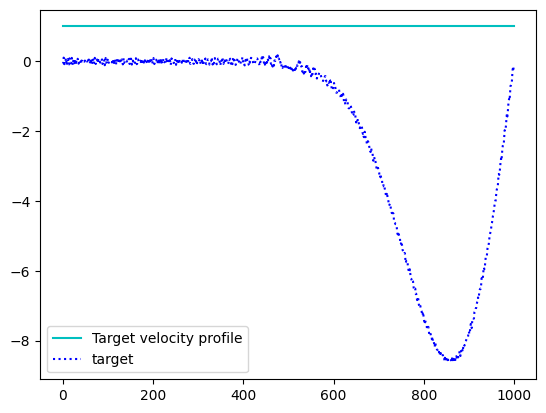

In [13]:
@jit
def wave_velocity(params):
    c = params
    dt = 5e-4
    # Sanity check the physical constants
    C = c*dt/dx
    C2 = C*C
    # C should be < 1 for stability

    # Set up initial conditions
    u0 = jnp.exp(-(5*(x0-0.5))**2)
    u1 = jnp.exp(-(5*(x0-0.5-c*dt))**2)
    u2 = jnp.zeros(n)
    def step(i, carry):
        u0, u1, u2 = carry
        # Shift right to get j - 1 and set the first value to 0
        u1p = jnp.roll(u1, 1)
        u1p = u1p.at[0].set(0)
        # Shift left to get j + 1 and set the last value to 0
        u1n = jnp.roll(u1, -1)
        u1n = u1n.at[n - 1].set(0)
        # Central difference in space and finite difference in time
        #  u2[j] = 2*u1[j] -u0[j] + C2*(u1[j-1]-2*u1[j]+u1[j+1])
        u2 = 2 * u1 - u0 + C2*(u1p -2*u1 +u1n)
        u0 = u1
        u1 = u2
        return (u0, u1, u2)
    # Space for time steps
    u0, u1, u2 = lax.fori_loop(0, 5000, step, (u0, u1, u2))

    # Velocity: u(t) - u(t-dt) / dt
    v_final = (u1-u0) / (dt)

    return v_final


# Assign target
ctarget = 1.0 # constant model
target = wave_velocity(ctarget)

# Velocity profile
plt.plot(jnp.ones(n) * ctarget, 'c', label='Target velocity profile')

plt.plot(target, 'b:', label='target')
plt.legend()
#plt.savefig("waves.png")
plt.show()

### Using Adam Optimizer

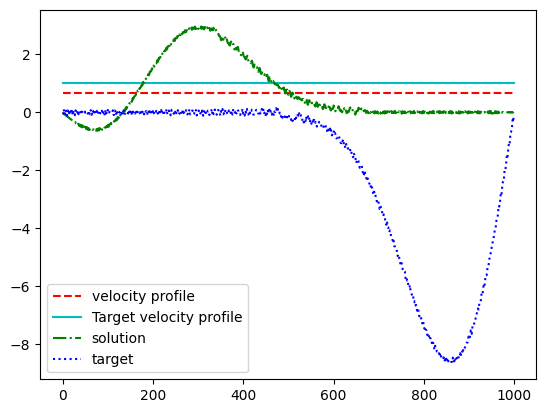

In [14]:
@jit
def compute_loss(c):
    v = wave_velocity(c)
    return jnp.linalg.norm(v - target)

# Gradient of forward problem
df = grad(compute_loss)

start_learning_rate = 1e-3
optimizer = optax.adam(start_learning_rate)

# Initialize parameters of the model + optimizer.
params =  0.85 # Constant model
opt_state = optimizer.init(params)

# A simple update loop.
for _ in range(1000):
  grads = grad(compute_loss)(params)
  updates, opt_state = optimizer.update(grads, opt_state)
  params = optax.apply_updates(params, updates)


# Velocity profile
plt.plot(jnp.ones(n) * params, 'r--', label='velocity profile')
plt.plot(jnp.ones(n) * ctarget, 'c', label='Target velocity profile')

# Waves
wave = wave_velocity(params)

plt.plot(wave, 'g-.', label='solution')
plt.plot(target, 'b:', label='target')
plt.legend()
plt.savefig("waves.png")

Initial loss: 5.126143e+01
Final loss: 1.118153e+00


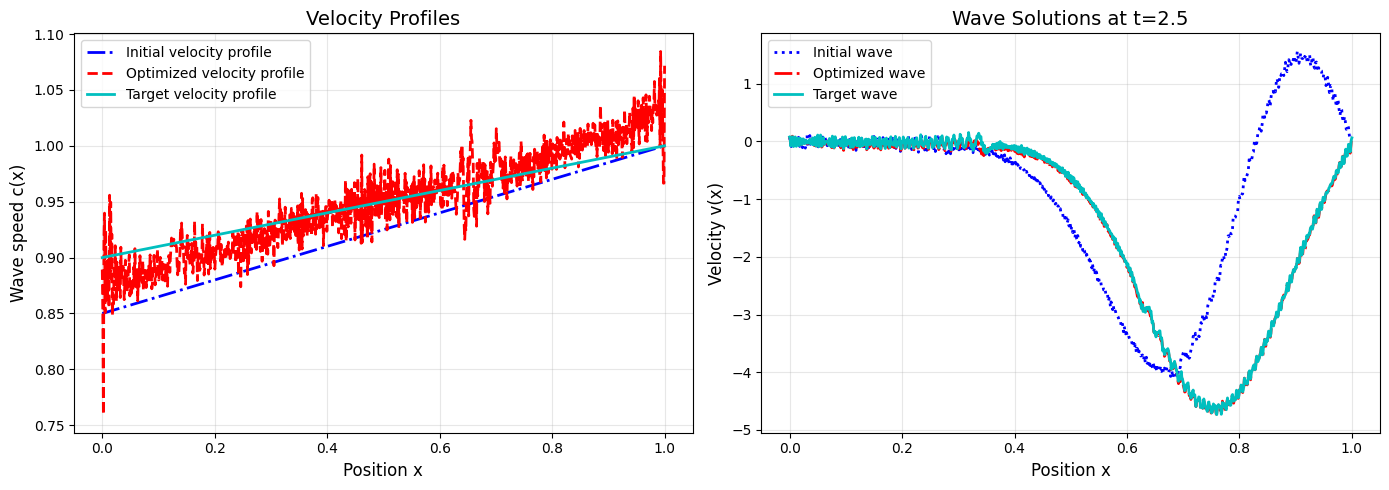

In [9]:
# Assign target
# ctarget = 1.0  # constant model
ctarget = jnp.linspace(0.9, 1.0, n)  # Linear model
target = wave_velocity(ctarget)


# Initialize parameters of the model
# params = 0.85  # Constant model
params = jnp.linspace(0.85, 1.0, n)


# Optimizers
def optax_adam(params, niter):
    """ADAM optimizer using Optax"""
    start_learning_rate = 1e-3
    optimizer = optax.adam(start_learning_rate)
    opt_state = optimizer.init(params)

    # A simple update loop
    for _ in range(niter):
        grads = grad(compute_loss)(params)
        updates, opt_state = optimizer.update(grads, opt_state)
        params = optax.apply_updates(params, updates)
    return params


def jaxopt_lbfgsb(params):
    """Bounded L-BFGS optimizer using JAXopt"""
    # Define bounds to ensure stability (C = c*dt/dx < 1)
    # For dt=5e-4, dx≈0.001, we need c < dx/dt ≈ 2.0
    lower_bounds = jnp.full_like(params, 0.1)  # Minimum wave speed
    upper_bounds = jnp.full_like(params, 1.5)  # Maximum wave speed

    solver = jaxopt.LBFGSB(
        fun=compute_loss,
        maxiter=100,
        tol=1e-5,
        maxls=20,  # Maximum line search iterations
    )

    result = solver.run(
        init_params=params,
        bounds=(lower_bounds, upper_bounds)
    )

    return result.params


# Choose optimizer
result = optax_adam(params, 1000)  # ADAM optimizer
#result = jaxopt_lbfgsb(params)  # Bounded L-BFGS optimizer

print(f"Initial loss: {compute_loss(params):.6e}")
print(f"Final loss: {compute_loss(result):.6e}")

# Velocity profile
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(x0, params, 'b-.', linewidth=2, label='Initial velocity profile')
plt.plot(x0, result, 'r--', linewidth=2, label='Optimized velocity profile')
plt.plot(x0, ctarget, 'c-', linewidth=2, label='Target velocity profile')
plt.xlabel('Position x', fontsize=12)
plt.ylabel('Wave speed c(x)', fontsize=12)
plt.title('Velocity Profiles', fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)

# Waves
plt.subplot(1, 2, 2)
velocity = wave_velocity(result)
init_velocity = wave_velocity(params)

plt.plot(x0, init_velocity, 'b:', linewidth=2, label='Initial wave')
plt.plot(x0, velocity, 'r-.', linewidth=2, label='Optimized wave')
plt.plot(x0, target, 'c-', linewidth=2, label='Target wave')
plt.xlabel('Position x', fontsize=12)
plt.ylabel('Velocity v(x)', fontsize=12)
plt.title('Wave Solutions at t=2.5', fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("waves.png", dpi=150, bbox_inches='tight')
plt.show()

### LBFGSB Optimizer

Initial loss: 5.126143e+01
Final loss: 1.127103e+00


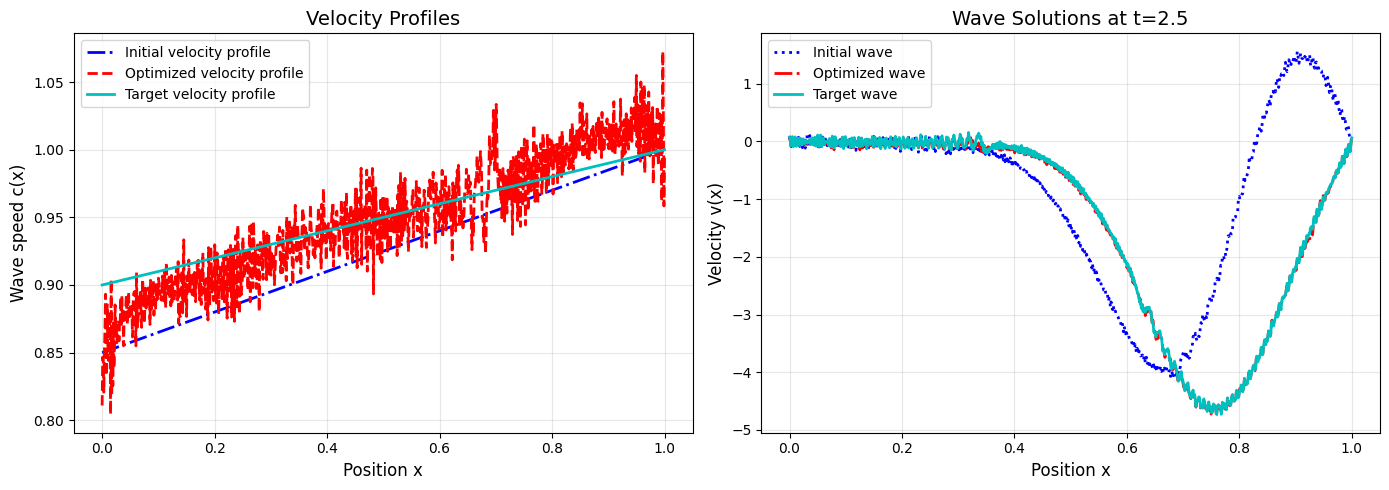

In [10]:

# Choose optimizer
#result = optax_adam(params, 1000)  # ADAM optimizer
result = jaxopt_lbfgsb(params)  # Bounded L-BFGS optimizer

print(f"Initial loss: {compute_loss(params):.6e}")
print(f"Final loss: {compute_loss(result):.6e}")

# Velocity profile
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(x0, params, 'b-.', linewidth=2, label='Initial velocity profile')
plt.plot(x0, result, 'r--', linewidth=2, label='Optimized velocity profile')
plt.plot(x0, ctarget, 'c-', linewidth=2, label='Target velocity profile')
plt.xlabel('Position x', fontsize=12)
plt.ylabel('Wave speed c(x)', fontsize=12)
plt.title('Velocity Profiles', fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)

# Waves
plt.subplot(1, 2, 2)
velocity = wave_velocity(result)
init_velocity = wave_velocity(params)

plt.plot(x0, init_velocity, 'b:', linewidth=2, label='Initial wave')
plt.plot(x0, velocity, 'r-.', linewidth=2, label='Optimized wave')
plt.plot(x0, target, 'c-', linewidth=2, label='Target wave')
plt.xlabel('Position x', fontsize=12)
plt.ylabel('Velocity v(x)', fontsize=12)
plt.title('Wave Solutions at t=2.5', fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("waves.png", dpi=150, bbox_inches='tight')
plt.show()

## Executive Summary
> Both optimizers gave an accurate prediction of the velocity profile, with Adam Optimizer having a slight higher accuracy.